## 🧬 LLM × Evolutionary Algorithms

### Learning objectives

- Practical — set up an LLM API (Gemini) and call it programmatically from Python.
- Technical — parse, compile and safely execute code emitted by an LLM.
- Research-oriented — evaluate LLM-generated meta-heuristics on a standard benchmark and iterate on them with simple evolutionary operators.
- Critical thinking — assess algorithmic ideas for correctness, novelty and computational efficiency.

### 1. Why are we doing this?

Modern Large Language Models (LLMs) are powerful tools that extend far beyond chatting. They can generate creative text, translate languages, write different kinds of content, and, importantly for us today, write code. We're going to explore how LLMs can be used to design new algorithms, drawing inspiration from how natural evolution works.

### 2. Environment setup

- Create / sign‑in to [Google AI Studio](https://aistudio.google.com/prompts/new_chat).
- Generate an API key and copy it


Install the SDK


In [1]:
! pip install google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 1.9 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


Verify it works.


In [ ]:
from google import genai
import os
API_KEY = os.getenv("GOOGLE_API_KEY")
MODEL = "gemini-2.0-flash"

client = genai.Client(api_key=API_KEY)

response = client.models.generate_content(model=MODEL, contents=["Hello, world!"])
print(response.text)

Hello there! How can I help you today?



If you see a greeting, you are good to go!

### Why Gemini?

We're using the Gemini API because it provides a generous free tier suitable for experimentation (e.g., 1500 free requests per day).


### 3. Large Language Models

The internal workings of LLMs are complex and beyond today's scope. For our purposes, we can treat an LLM as a sophisticated "text-to-text" function. A key strength of modern LLMs is their ability to understand and generate code in various programming languages. We'll leverage this today.

Let's start with a simple example:

> Problem: You are given a list of integers from 1 to n, with exactly one number missing. Write a Python function to find the missing number.


In [2]:
PROMPT = """
Problem: You are given a list of integers from 1 to n, with exactly one number missing. 
Write a Python function to find the missing number.
"""

response = client.models.generate_content(model=MODEL, contents=[PROMPT])
print(response.text)

```python
def find_missing_number(numbers):
  """
  Finds the missing number in a list of integers from 1 to n, with one number missing.

  Args:
    numbers: A list of integers from 1 to n, with one number missing.

  Returns:
    The missing number.  Returns None if the input list is invalid (e.g., empty, contains duplicates, or values outside the expected range).
  """

  n = len(numbers) + 1  # Calculate the expected value of n (including the missing number)

  # Check for edge cases and input validation:
  if not numbers:
    return None  # Empty list

  # Verify if the numbers are within the valid range and are unique:
  seen = set()
  for num in numbers:
    if not (1 <= num <= n):
      return None  # Number out of range
    if num in seen:
      return None  # Duplicate number found
    seen.add(num)


  expected_sum = n * (n + 1) // 2  # Sum of integers from 1 to n
  actual_sum = sum(numbers)

  return expected_sum - actual_sum

# Example Usage:
numbers1 = [1, 2, 4, 6, 3, 7, 

This is a good start, but the LLM might return explanatory text along with the code, or the code might not be in a directly usable format. For systematic use, we need more control.

To make the LLM's output reliable for our task, we will:

1. Force a Specific Function Signature: We'll instruct the LLM to define a function with a name and parameters we choose.
2. Parse the Code: We'll extract the Python code from the LLM's response (which is often formatted in Markdown).
3. Verify and Execute: We'll compile the extracted code and then test it against predefined test cases.


In [3]:
PROMPT_WITH_SIGNATURE = """
Problem: You are given a list of integers from 1 to n, with exactly one number missing. 
Write a Python function to find the missing number.

Your solution should we wrapped in a Markdown Python block code. 
```python
def find_missing_number(numbers: list[int]) -> int:
    ...
```
"""

response = client.models.generate_content(model=MODEL, contents=[PROMPT_WITH_SIGNATURE])
print(response.text)

```python
def find_missing_number(numbers: list[int]) -> int:
    """
    You are given a list of integers from 1 to n, with exactly one number missing. 
    Write a Python function to find the missing number.
    """
    n = len(numbers) + 1
    expected_sum = n * (n + 1) // 2
    actual_sum = sum(numbers)
    return expected_sum - actual_sum
```


We can see that LLM was able to follow our instructions. Right now we need to parse the result:


In [4]:
import ast
import re
from typing import Any, Callable


class FunctionParser:
    @staticmethod
    def parse(
        model_response: str, function_name: str
    ) -> Callable[[list[int]], int] | None:
        function_str = FunctionParser.extract_code(model_response)
        if not function_str:
            print("No function found in response")
            return None

        if not FunctionParser.validate_function_syntax(function_str):
            print("Invalid function syntax")
            return None

        namespace: dict[str, Any] = {}
        # WARNING: This is not safe and should not be used in production
        # This should be run in a sandboxed environment
        exec(function_str, namespace)
        return namespace[function_name]

    @staticmethod
    def validate_function_syntax(function_str: str) -> bool:
        try:
            ast.parse(function_str)
            return True
        except SyntaxError:
            return False

    @staticmethod
    def extract_code(text: str) -> str | None:
        pattern = r"```python\s*(.*?)\s*```"
        match = re.search(pattern, text, re.DOTALL)
        return match.group(1) if match else None


function = FunctionParser.parse(response.text, "find_missing_number")

We can also verify if the result is correct:


In [5]:
assert function([1, 3, 4, 5]) == 2

We can implement automatic verification methods, including those that quantify the quality of our function. A simple yet effective metric is the percentage of test cases passed.


In [6]:
from typing import Generator
import random


class FunctionVerifier:
    def __init__(
        self,
        sizes: list[int] | None = None,
        *,
        rng_seed: int | None = None,
    ) -> None:
        self.sizes = sizes if sizes is not None else [5, 10, 20]
        self._rng = random.Random(rng_seed)

    def _test_cases(self) -> Generator[tuple[list[int], int], None, None]:
        for n in self.sizes:
            full = list(range(1, n + 1))
            for idx in range(n):
                data = full.copy()
                missing = data.pop(idx)
                self._rng.shuffle(data)
                yield data, missing

    def verify(
        self,
        func: Callable[[list[int]], int],
    ) -> float:
        solved = 0
        total = 0

        for data, expected in self._test_cases():
            try:
                result = func(data.copy())
                if result == expected:
                    solved += 1
            except Exception as e:
                print(f"Error during test case execution: {e}")
            total += 1

        return solved / total if total > 0 else 0.0


verifier = FunctionVerifier()
test_pass_rate = verifier.verify(function)
print(f"Test pass rate: {test_pass_rate:.2%}")

Test pass rate: 100.00%


So, we've established that LLMs can generate Python functions, and we can programmatically parse and verify their correctness. This forms the foundation for using LLMs in more complex algorithmic tasks, especially when combined with evolutionary approaches!


### 4. LLM × Evolutionary Algorithms

How can large language models be leveraged for optimization? One promising direction is to employ LLMs to generate novel optimization algorithms in much the same way they are used to synthesize problem-solving functions. Given that algorithms can be expressed as Python functions, this presents a natural and flexible framework for exploring algorithmic design via language models.


In [7]:
PROMPT_METAHEURISTIC = """
Problem: You are tasked with inventing a novel metaheuristic algorithm capable of minimizing an arbitrary real-valued, 
black-box, single-objective function defined over simple bound constraints.

Write a Python function that implements your algorithm. The function must take exactly these arguments:
- function: Callable[np.ndarray], float] - the objective function to minimise.
- bounds: list[tuple[float, float]] - a list of (lower, upper) pairs delimiting the search space for each dimension.
- budget: int - the total number of objective-function evaluations the algorithm may perform.

The function should return a tuple[float, np.ndarray] containing the best objective value found and the corresponding decision vector.

Your solution should be wrapped in a Markdown Python code block.

```python
import numpy as np 

def new_metaheuristic(
	function: Callable[[np.ndarray], float], 
    bounds: list[tuple[float, float]], 
    budget: int
) -> tuple[float, np.ndarray]:
    ...
```
"""

response = client.models.generate_content(model=MODEL, contents=[PROMPT_METAHEURISTIC])
print(response.text)

```python
import numpy as np
from typing import Callable, List, Tuple

def new_metaheuristic(
    function: Callable[[np.ndarray], float],
    bounds: List[Tuple[float, float]],
    budget: int
) -> Tuple[float, np.ndarray]:
    """
    A novel metaheuristic algorithm for minimizing a black-box function.

    This algorithm is a simplified variant of Differential Evolution (DE).  It
    maintains a population of candidate solutions and iteratively evolves them
    by mutation, crossover, and selection.

    Args:
        function: The objective function to minimize.
        bounds: A list of (lower, upper) pairs delimiting the search space.
        budget: The total number of function evaluations allowed.

    Returns:
        A tuple containing the best objective value found and the corresponding
        decision vector.
    """

    dim = len(bounds)
    population_size = min(10*dim, 50) # dynamically adjust population size
    
    # Ensure budget is sufficient for at least one popu

### Exercise 1:

Describe the meta‑heuristic generated by Gemini. Does the idea make sense? Is it novel? What are its weaknesses?


Well, yes the meta-heuristic generated by Gemini does make sense. The proposed algorithm is a simplified variant of Differential Evolution. It
maintains a population of candidate solutions and iteratively evolves them by mutation, crossover, and selection. I wouldn't say that it is novel. It is a well-known algorithm in the field of evolutionary computation. However, it does have some weaknesses, biggest one is not being adaptive.


Let's parse it:


In [8]:
metaheuristic = FunctionParser.parse(response.text, "new_metaheuristic")

And quantify its quality (average across 10 runs for Rastrigin in 10D):


In [9]:
import random
from typing import Callable, Generator

import numpy as np


def rastrigin(x: np.ndarray) -> float:
    A: float = 10.0
    return float(A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x)))


class OptimizerVerifier:
    def __init__(
        self,
        budget: int = 10_000,
        dims: int = 10,
        seeds_count: int = 10,
        test_function: Callable = rastrigin,
    ) -> None:
        self.budget = budget
        self.dims = dims
        self.seeds_count = seeds_count
        self.test_function = test_function

    def verify(
        self,
        optimizer: Callable,
    ) -> dict[str, float]:
        bounds = [(-5, 5) for _ in range(self.dims)]
        results = []
        for seed in range(self.seeds_count):
            np.random.seed(seed)
            random.seed(seed)
            best_val, _ = optimizer(self.test_function, bounds, self.budget)
            results.append(best_val)
        return np.mean(best_val)


verifier = OptimizerVerifier()
mean_score_for_rastrigin = verifier.verify(metaheuristic)
mean_score_for_rastrigin

np.float64(58.42439807555945)

Now let's go one step further. We can calculate the quality (fitness function) for each solution (metaheuristic) generated by LLM. In this case we can try to apply crossover/mutation operators to textual solutions. We can visualize it as optimization process in the space of Python functions that represent different optimization algorithms.

### Exercise 2:

Review [Evolution of Heuristics: Towards Efficient Automatic Algorithm Design Using Large Language Model](https://arxiv.org/pdf/2401.02051) and read **3.4 Prompt Strategies**. Re-implement one of the prompt strategies from **3.4 Prompt Strategies** of Evolution of Heuristics. Generate N = 5 distinct algorithms, benchmark them and report the best.


In [21]:
results = {}
for i in range(5):
    response = client.models.generate_content(
        model=MODEL, contents=[PROMPT_METAHEURISTIC]
    )

    metaheuristic = FunctionParser.parse(response.text, "new_metaheuristic")

    verifier = OptimizerVerifier()
    mean_score_for_rastrigin = verifier.verify(metaheuristic)
    results[i] = []
    results[i].append(metaheuristic)
    results[i].append(response)
    results[i].append(mean_score_for_rastrigin)
    print(f"{i}. mean score for Rastrigin: {mean_score_for_rastrigin:.2f}")

0. mean score for Rastrigin: 37.86
1. mean score for Rastrigin: 25.81
2. mean score for Rastrigin: 22.89
3. mean score for Rastrigin: 17.91
4. mean score for Rastrigin: 35.13


In [26]:
COLLECTED_METAHEURISTICS = ""
for i in range(5):
    fstring = f"No.{i + 1} Heuristic description:\n"
    fstring += results[i][1].text + "\n\n"
    COLLECTED_METAHEURISTICS += fstring

print(COLLECTED_METAHEURISTICS)

No.1 Heuristic description:
```python
import numpy as np
from typing import Callable, List, Tuple

def new_metaheuristic(
    function: Callable[[np.ndarray], float],
    bounds: List[Tuple[float, float]],
    budget: int
) -> Tuple[float, np.ndarray]:
    """
    A novel metaheuristic algorithm for minimizing a black-box function
    subject to bound constraints. This implementation uses a simplified
    particle swarm optimization (PSO) variant with random restarts.

    Args:
        function: The objective function to minimize.
        bounds: A list of (lower, upper) bounds for each dimension.
        budget: The total number of function evaluations allowed.

    Returns:
        A tuple containing the best objective value found and the
        corresponding decision vector.
    """

    dimension = len(bounds)
    swarm_size = min(100, budget // 10)  # Adjust swarm size based on budget
    inertia_weight = 0.5
    cognitive_coefficient = 1.5
    social_coefficient = 1.5

    best

In [27]:
E2_PROMPT = f"""
I need help designing metaheuristic algorithm capable of minimizing an arbitrary real-valued, 
black-box, single-objective function defined over simple bound constraints.
I have five existing heuristics with their codes as follows:
{COLLECTED_METAHEURISTICS}
Please help me design a new heuristic that is different from the given ones
but can be motivated by them.
Firstly, identify the common idea in the provided heuristics.
Secondly, based on the backbone idea describe your new heuristic in one
sentence.
Thirdly, implement it in Python as a function named 'new_metaheuristic'. The function must take exactly these arguments:
- function: Callable[np.ndarray], float] - the objective function to minimise.
- bounds: list[tuple[float, float]] - a list of (lower, upper) pairs delimiting the search space for each dimension.
- budget: int - the total number of objective-function evaluations the algorithm may perform.

The function should return a tuple[float, np.ndarray] containing the best objective value found and the corresponding decision vector.

Your solution should be wrapped in a Markdown Python code block.

```python
import numpy as np 

def new_metaheuristic(
	function: Callable[[np.ndarray], float], 
    bounds: list[tuple[float, float]], 
    budget: int
) -> tuple[float, np.ndarray]:
    ...
```
"""

In [28]:
response = client.models.generate_content(model=MODEL, contents=[E2_PROMPT])
metaheuristic = FunctionParser.parse(response.text, "new_metaheuristic")
verifier = OptimizerVerifier()
mean_score_for_rastrigin = verifier.verify(metaheuristic)
print(f"Mean score for Rastrigin: {mean_score_for_rastrigin:.2f}")
print("Generated metaheuristic code:")
print(response.text)

Mean score for Rastrigin: 39.21
Generated metaheuristic code:
```python
import numpy as np
from typing import Callable, List, Tuple

def new_metaheuristic(
    function: Callable[[np.ndarray], float],
    bounds: List[Tuple[float, float]],
    budget: int
) -> Tuple[float, np.ndarray]:
    """
    A metaheuristic algorithm that combines aspects of population-based search with a gradient-free local search strategy,
    adaptively shifting the focus between global exploration and local exploitation based on performance feedback.
    """
    dimension = len(bounds)
    population_size = min(50, budget // 20)
    if population_size < 5:
        population_size = 5

    # Initialize population within bounds
    population = np.random.rand(population_size, dimension)
    for i in range(dimension):
        population[:, i] = population[:, i] * (bounds[i][1] - bounds[i][0]) + bounds[i][0]

    fitness = np.array([function(x) for x in population])
    evaluations = population_size

    best_ind

Run one of these operators, and try to explain what happened? Are the new mutated solution better than previous one? Calculate the quality of new solution and old ones.


### Exercise 3:

Implement Evolution of Heuristics (or at least part of it). Start simple (pseudocode):

```
current_population = [generate_heuristic()]
for _ in range(10):
   parents = current_population[-p:]
   new_solution = E1(parents) # Read 3.4. Prompt Strategies to better understand E1
   f_new_solution = verify(new_solution)
   current_population.append(new_solution)
```

Save all solutions (best would be to have a separate file for each one). Analyse 5 different ones. Plot quality of solution per epoch. Is this iterative process converging?


In [ ]:
NUM_ITERATIONS = 20
POPULATION_FILE_DIR = "heuristics_population"
os.makedirs(POPULATION_FILE_DIR, exist_ok=True)


In [ ]:
def generate_initial_heuristics(n: int = 5):
    collected_metaheuristics = ""
    results = []

    for i in range(n):
        response = client.models.generate_content(
            model=MODEL, contents=[PROMPT_METAHEURISTIC]
        )
        code_text = response.text.strip()
        collected_metaheuristics += (
            f"No.{i + 1} Heuristic description:\n{code_text}\n\n"
        )

        metaheuristic = FunctionParser.parse(code_text, "new_metaheuristic")

        verifier = OptimizerVerifier()
        score = verifier.verify(metaheuristic)

        result = [metaheuristic, response, score, code_text]
        results.append(result)

        with open(f"{POPULATION_FILE_DIR}/heuristic_{i + 1}.py", "w") as f:
            f.write(code_text)

    return results, collected_metaheuristics

In [ ]:
def update_prompt(collected_metaheuristics: str) -> str:
    return f"""
I need help designing metaheuristic algorithm capable of minimizing an arbitrary real-valued, 
black-box, single-objective function defined over simple bound constraints.
I have five existing heuristics with their codes as follows:
{collected_metaheuristics}
Please help me design a new heuristic that is different from the given ones
but can be motivated by them.

Firstly, identify the common idea in the provided heuristics.
Secondly, based on the backbone idea describe your new heuristic in one sentence.
Thirdly, implement it in Python as a function named 'new_metaheuristic'. The function must take exactly these arguments:
- function: Callable[np.ndarray], float] - the objective function to minimise.
- bounds: list[tuple[float, float]] - a list of (lower, upper) pairs delimiting the search space for each dimension.
- budget: int - the total number of objective-function evaluations the algorithm may perform.

The function should return a tuple[float, np.ndarray] containing the best objective value found and the corresponding decision vector.

Your solution should be wrapped in a Markdown Python code block.
"""

In [ ]:
def rank_heuristics(results: list[list[Any]]):
    return sorted(results, key=lambda x: x[2])

In [ ]:
def select_parents(results: list[list[Any]], num_parents: int = 5):
    ranked = rank_heuristics(results)
    total_ranked = len(ranked)

    weights = np.array([1 / (1 + i) for i in range(total_ranked)])
    probabilities = weights / weights.sum()

    selected_indices = np.random.choice(
        len(ranked), size=num_parents, replace=False, p=probabilities
    )
    selected = [ranked[i] for i in selected_indices]
    return selected

In [44]:
current_population, collected_metaheuristics = generate_initial_heuristics()

for iteration in range(NUM_ITERATIONS):
    print(f"\n--- Iteration {iteration + 1} ---")

    parents = select_parents(current_population, num_parents=5)
    collected_metaheuristics = ""
    for idx, parent in enumerate(parents):
        collected_metaheuristics += (
            f"No.{idx + 1} Heuristic description:\n{parent[3]}\n\n"
        )

    prompt = update_prompt(collected_metaheuristics)
    response = client.models.generate_content(model=MODEL, contents=[prompt])
    code_text = response.text.strip()

    try:
        new_metaheuristic = FunctionParser.parse(code_text, "new_metaheuristic")
        verifier = OptimizerVerifier()
        score = verifier.verify(new_metaheuristic)

        result = [new_metaheuristic, response, score, code_text]
        current_population.append(result)

        with open(
            f"{POPULATION_FILE_DIR}/heuristic_{len(current_population)}.py", "w"
        ) as f:
            f.write(code_text)

        print(f"Generated new heuristic with score: {score:.4f}")

    except Exception as e:
        print(f"Error parsing or verifying new heuristic: {e}")



--- Iteration 1 ---
Generated new heuristic with score: 51.1665

--- Iteration 2 ---
Generated new heuristic with score: 56.6166

--- Iteration 3 ---
Generated new heuristic with score: 33.1139

--- Iteration 4 ---
Generated new heuristic with score: 38.8157

--- Iteration 5 ---
Generated new heuristic with score: 25.4070

--- Iteration 6 ---
Generated new heuristic with score: 52.7072

--- Iteration 7 ---
Generated new heuristic with score: 19.0089

--- Iteration 8 ---
Generated new heuristic with score: 1.1620

--- Iteration 9 ---
Generated new heuristic with score: 21.2465

--- Iteration 10 ---
Generated new heuristic with score: 2.3400

--- Iteration 11 ---
Generated new heuristic with score: 26.6936

--- Iteration 12 ---
Generated new heuristic with score: 74.6260

--- Iteration 13 ---
Generated new heuristic with score: 58.8646

--- Iteration 14 ---
Generated new heuristic with score: 93.8543

--- Iteration 15 ---
Generated new heuristic with score: 34.7360

--- Iteration 16 ---

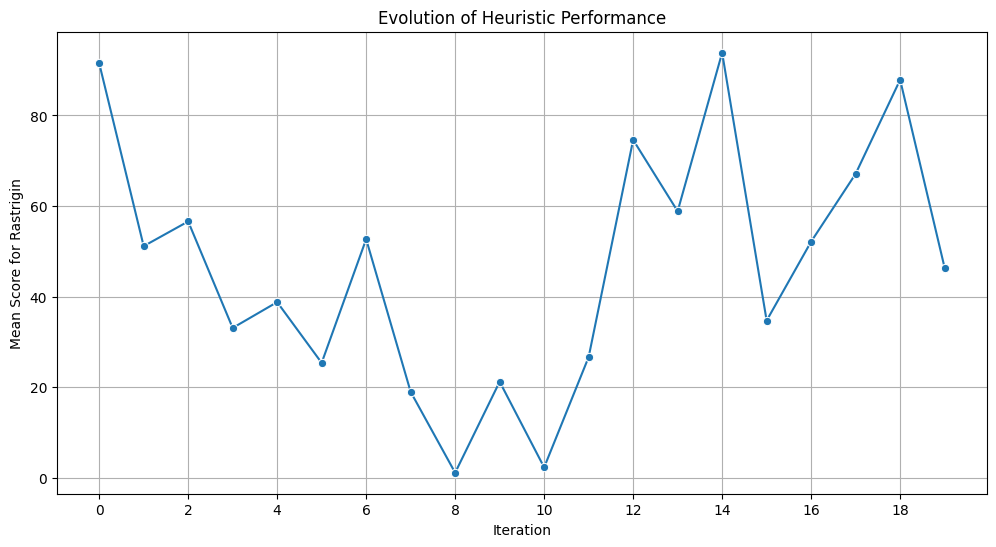

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(
    x=list(range(0, NUM_ITERATIONS)),
    y=[result[2] for result in current_population[4:]],
    marker="o",
)
plt.xlabel("Iteration")
plt.ylabel("Mean Score for Rastrigin")
plt.title("Evolution of Heuristic Performance")
plt.xticks(range(0, NUM_ITERATIONS, 2))
plt.grid()
plt.show()

I might did something wrong, because the quality of the solution is not really improving, at least that does not seem to be te case. In the paper it was said that for the bag problem it took them around 20 iterations to converge. I got best solutions somewhere in the middle, in 8th and 10th iteration.

### Description of generated meta-heuristic of choice

1. A metaheuristic that combines aspects of particle swarm optimization (PSO) and covariance matrix adaptation evolution strategy (CMA-ES) with a budget-aware adaptation mechanism. (best, 8th iteration)
2. This metaheuristic combines aspects of population-based search with the shrinking bound approach, using a diverse population that gradually focuses its search within tighter bounds around the best solutions found so far. (2nd best, 10th iteration)
3. This metaheuristic, inspired by the given algorithms, adaptively combines global exploration via differential evolution with local refinement using a Nelder-Mead simplex method, balancing the two based on budget and solution improvement. (worst, 14th iteration)
4. A metaheuristic algorithm that combines the exploration of a diverse population with the intensification of a trust-region-like method, adapting the trust region size based on search progress. (2nd worst, 12th iteration)
5. Evolutionary algorithm that dynamically balances exploration and exploitation based on population performance. (3rd best, 7th iteration)


### Call to Action

The GECCO 2025 conference is hosting a [competition](https://gecco-2025.sigevo.org/Competition?itemId=5104) on LLM-designed Evolutionary Algorithms. If you’re interested in collaborating and participating as a team, feel free to send me a direct message. Let’s explore the opportunity together.


### 5. Recommended Reading

- [AlphaEvolve: A Gemini-powered coding agent for designing advanced algorithms](https://deepmind.google/discover/blog/alphaevolve-a-gemini-powered-coding-agent-for-designing-advanced-algorithms/)
- Shojaee, Parshin, et al. [LLM-SR: Scientific equation discovery via programming with large language models.](https://arxiv.org/abs/2404.18400)
- Romera-Paredes, Bernardino, et al. [Mathematical discoveries from program search with large language models.](https://www.nature.com/articles/s41586-023-06924-6)
- van Stein, Niki, and Thomas Bäck. [Llamea: A large language model evolutionary algorithm for automatically generating metaheuristics.](https://arxiv.org/abs/2405.20132)
- Liu, Fei, et al. [Evolution of heuristics: Towards efficient automatic algorithm design using large language model.](https://arxiv.org/abs/2401.02051)
- van Stein, Niki, et al. [BLADE: Benchmark suite for LLM-driven Automated Design and Evolution of iterative optimisation heuristics](https://arxiv.org/html/2504.20183v1)
- [OpenEvolve](https://github.com/codelion/openevolve)
